In [1]:
import os

os.environ['CUDA_VISIBLE_DEVICES'] = '0'

In [2]:
%cd ../

/net/csefiles/coc-fung-cluster/Qianyu/stable_md/MatDeepLearn_dev


In [3]:
import numpy as np

rank = "cuda:0" # device
batch_size = 4
save_dir = 'data/silica_10%_5aug/' # path to save augmented data
pull_max_strength = np.linspace(1.0, 0., 5) # strength of pulling
perturb_max_strength = np.linspace(1.0, 0., 5) # strength of perturbation
std = 0.1
task = "simulation" # optimization doesn't need labels
n_pairs_to_choose = 2
n_perturb_sites = 5
n_round_augmentation = 5
seed = 42

In [4]:
dataset = 'Silica'
if dataset == "Silica":
    original_data_path = "/net/csefiles/coc-fung-cluster/Qianyu/data/Silica/original/data.json"
    calculator_path = 'configs/calculator/Silica/potential_only/config_eam_interaction.yml'
    calculated_properties = ('energy', 'forces', 'stress')
elif dataset == "P":
    original_data_path = "/net/csefiles/coc-fung-cluster/Qianyu/p/train_val_data.json"
    calculator_path = 'configs/calculator/phosphorous/potential_only/config_eam_interaction.yml'
    calculated_properties = ('energy', 'forces')
elif dataset == 'mp_subset':
    original_data_path = "/net/csefiles/coc-fung-cluster/Qianyu/Li-O-P-Mn-Subset/data.json"
    calculator_path = 'configs/calculator/mp_subset/potential_only/config_eam_interaction.yml'
    calculated_properties = ('energy', 'forces', 'stress')

In [5]:
import pandas as pd

df_train = pd.read_csv('results/eam/silica/2025-05-24-22-02-58-339-silica_eam_10%/train_results/train_predictions.csv')
df_val = pd.read_csv('results/eam/silica/2025-05-24-22-02-58-339-silica_eam_10%/train_results/val_predictions.csv')
names = set(df_train['structure_id'].apply(lambda x: str(x)).values).union(set(df_val['structure_id'].apply(lambda x: str(x)).values))
len(names)

271

In [6]:
import json
import numpy as np

with open(original_data_path, 'r') as f:
    data = json.load(f)

print(len(data))
data = [d for d in data if d['structure_id'] in names]
structures = [{key: np.array(val) if isinstance(val, list) else val for key, val in dt.items()} for dt in data]
len(data)

2864


271

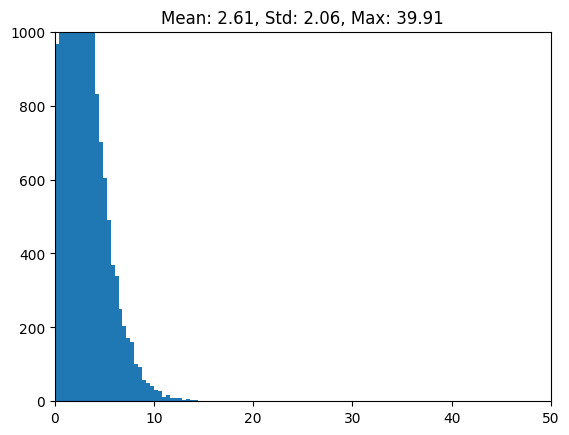

In [7]:
import matplotlib.pyplot as plt

orig_forces = np.concatenate([structure['forces'] for structure in structures])
force_magnitude = np.linalg.norm(orig_forces, axis=1)
plt.hist(force_magnitude, bins=100)
plt.title(f"Mean: {np.mean(force_magnitude):.2f}, Std: {np.std(force_magnitude):.2f}, Max: {np.max(force_magnitude):.2f}")
plt.xlim(left=0, right=50)
plt.ylim(bottom=0, top=1000)
plt.show();

In [8]:
from ase.cell import Cell
from ase import Atoms

def get_atoms(structure):
    if structure['cell'].ndim == 3:
        cell = Cell(structure['cell'][0])
    else:
        cell = Cell(structure['cell'])
    atoms = Atoms(
        symbols=structure['atomic_numbers'],
        positions=structure['positions'],
        cell=cell,
        pbc=[True] * 3
    )
    atoms.structure_id = structure['structure_id']
    return atoms

In [9]:
from itertools import combinations_with_replacement

def get_closest_pairs(atoms: Atoms, n_pairs: int = n_pairs_to_choose):
    all_distances = atoms.get_all_distances(mic=True)

    # Create list of all unique pairs and their distances
    n_atoms = len(atoms)
    pairs_and_distances = []
    for i in range(n_atoms):
        for j in range(i+1, n_atoms):
            pairs_and_distances.append((i, j, all_distances[i,j]))
            
    pairs_and_distances.sort(key=lambda x: x[2])

    # Select n pairs with no shared atoms
    closest_pairs = []
    used_atoms = set()
    
    for i, j, dist in pairs_and_distances:
        if len(closest_pairs) >= n_pairs:
            break
        
        # Skip if either atom is already used
        if i in used_atoms or j in used_atoms:
            continue
            
        closest_pairs.append((i, j, dist))
        used_atoms.add(i)
        used_atoms.add(j)
    
    return closest_pairs

def get_sorted_distances(atoms: Atoms):
    all_distances = atoms.get_all_distances(mic=True)
    pairs = []
    for i in range(len(atoms)):
        for j in range(i+1, len(atoms)):
            if i != j:
                pairs.append((i, j, all_distances[i, j]))
    pairs.sort(key=lambda x: x[2])
    return pairs

def get_min_distance(atoms: Atoms):
    all_distances = atoms.get_all_distances(mic=True)
    atom_types = atoms.get_atomic_numbers()
    interaction_types = combinations_with_replacement(set(atom_types), 2)
    min_distance_per_interaction = {}
    for interaction in interaction_types:
        indices = np.where(np.isin(atom_types, interaction))[0]
        if len(indices) < 2:
            continue
        distances = all_distances[np.ix_(indices, indices)]
        min_distance = np.min(distances[np.nonzero(distances)])
        min_distance_per_interaction[interaction] = min_distance
    return min_distance_per_interaction

In [10]:
def pull_atoms(atoms: Atoms, eps: float, random='uniform', std=None) -> Atoms:
    a = atoms.copy() 
    closest_pairs = get_closest_pairs(a)
    modified_pairs = []
    pull_distances = []

    positions = a.get_positions()

    for i, j, _ in closest_pairs:
        # Sample random pull distance
        if random == 'uniform':
            pull_dist = np.random.uniform(0, eps)
        else:
            assert std is not None
            pull_dist = np.random.normal(eps, std)
        pull_distances.append(pull_dist)
        
        pos_i = positions[i]
        pos_j = positions[j]
        
        if any(a.get_pbc()):
            diff = a.get_distance(i, j, mic=True, vector=True)
        else:
            diff = pos_j - pos_i
            
        direction = diff / np.linalg.norm(diff)        
        positions[i] += direction * (pull_dist/2)
        positions[j] -= direction * (pull_dist/2)
        
        modified_pairs.append((i, j))
        
    a.set_positions(positions)
    return a

In [11]:
def random_perturb(atoms: Atoms, n_perturb_sites: int, eps: float, random='uniform', std=None) -> Atoms:
    a = atoms.copy()
    positions = a.get_positions()
    n_atoms = len(a)
    
    perturbed_sites = np.random.choice(n_atoms, n_perturb_sites, replace=False)
    rand_unit_vectors = np.random.randn(n_perturb_sites, 3)
    rand_unit_vectors /= np.linalg.norm(rand_unit_vectors, axis=1)[:, np.newaxis]

    if random == 'uniform':
        perturb_strengths = np.random.uniform(0, eps, n_perturb_sites)
    else:
        assert std is not None
        perturb_strengths = np.random.normal(eps, std, n_perturb_sites)

    positions[perturbed_sites] += rand_unit_vectors * perturb_strengths[:, np.newaxis]
        
    a.set_positions(positions)
    return a

In [12]:
from tqdm import tqdm

np.random.seed(seed)

modified_atoms_list = []
if n_round_augmentation < 1:
    indices = np.random.choice(
        len(structures),
        int(n_round_augmentation * len(structures)),
        replace=False
    )
    original_atoms_list = [get_atoms(structures[i]) for i in indices]
    modified_atoms_list = [
        random_perturb(
            pull_atoms(
                atoms, pull_max_strength[0], 'uniform', std=std
            ),
            min(n_perturb_sites, len(atoms)), perturb_max_strength[0], 'uniform', std=std
        ) for atoms in original_atoms_list
    ]
else:
    for i in range(n_round_augmentation):
        original_atoms_list= [get_atoms(structure) for structure in structures]
        modified_atoms_list += [
            random_perturb(
                pull_atoms(
                    atoms, pull_max_strength[i], 'uniform', std=std
                ),
                min(n_perturb_sites, len(atoms)), perturb_max_strength[i], 'uniform', std=std
            ) for atoms in tqdm(original_atoms_list)
        ]
        
modified_atoms_list = list(filter(lambda x: len(x) > 1, modified_atoms_list))

  4%|▎         | 10/271 [00:00<00:02, 93.76it/s]

100%|██████████| 271/271 [00:04<00:00, 66.23it/s] 


In [13]:
from matdeeplearn.common.ase_utils import MDLCalculator

calc = MDLCalculator(calculator_path)

INFO:root:MDLCalculator instantiated from config: configs/calculator/Silica/potential_only/config_eam_interaction.yml
INFO:root:MDLCalculator: setting up EAM_Interaction for calculation
INFO:root:MDLCalculator: weights for model No.1 loaded from results/eam/silica/2025-05-24-22-02-58-339-silica_eam_10%/checkpoint_0/best_checkpoint.pt


In [14]:
from tqdm import tqdm
from ase.calculators.singlepoint import SinglePointCalculator

for atoms in tqdm(modified_atoms_list):
    if len(atoms) <= 1:
        continue
    calc.calculate(atoms, properties=calculated_properties)
    atoms.calc = SinglePointCalculator(
        atoms,
        energy=calc.results['energy'],
        forces=calc.results['forces'],
        stress=calc.results['stress']
    )

100%|██████████| 1355/1355 [00:11<00:00, 119.87it/s]


In [15]:
def atoms2dict(atoms: Atoms, structure_id: str) -> dict:
    return {
        'structure_id': structure_id,
        'atomic_numbers': atoms.get_atomic_numbers().tolist(),
        'positions': atoms.get_positions().tolist(),
        'cell': atoms.get_cell().array.tolist(),
        'pbc': atoms.get_pbc().tolist(),
        'y': atoms.get_potential_energy().item(),
        'forces': atoms.get_forces().tolist(),
        'stress': [atoms.get_stress(voigt=False).tolist()]
    }

In [16]:
structures_to_write = [
    atoms2dict(atoms, str(idx)) for idx, atoms in enumerate(modified_atoms_list)
]

In [17]:
energies = np.array([s['y'] for s in structures_to_write])
force_magnitudes = np.array([np.linalg.norm(s['forces']) for s in structures_to_write])

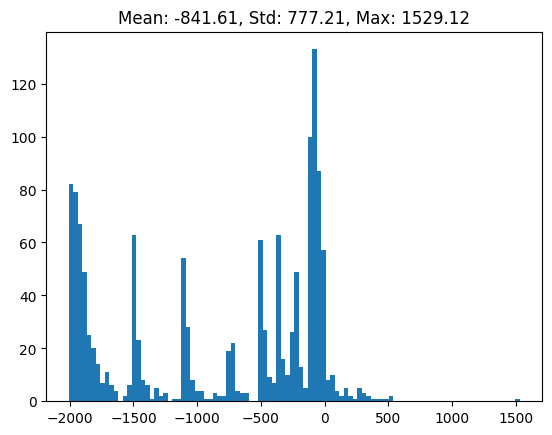

In [18]:
plt.hist(energies, bins=100)
plt.title(f"Mean: {np.mean(energies):.2f}, Std: {np.std(energies):.2f}, Max: {np.max(energies):.2f}")
plt.plot();

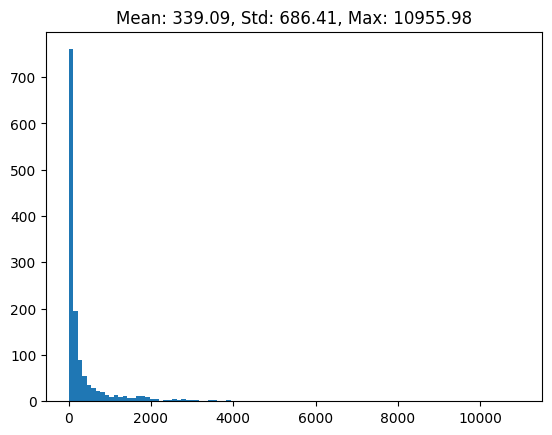

In [19]:
plt.hist(force_magnitudes, bins=100)
plt.title(f"Mean: {np.mean(force_magnitudes):.2f}, Std: {np.std(force_magnitudes):.2f}, Max: {np.max(force_magnitudes):.2f}")
plt.plot();

In [20]:
import json, os

os.makedirs(save_dir, exist_ok=True)
with open(save_dir + 'data.json', 'w') as f:
    json.dump(structures_to_write, f)

In [21]:
len(structures_to_write)

1355